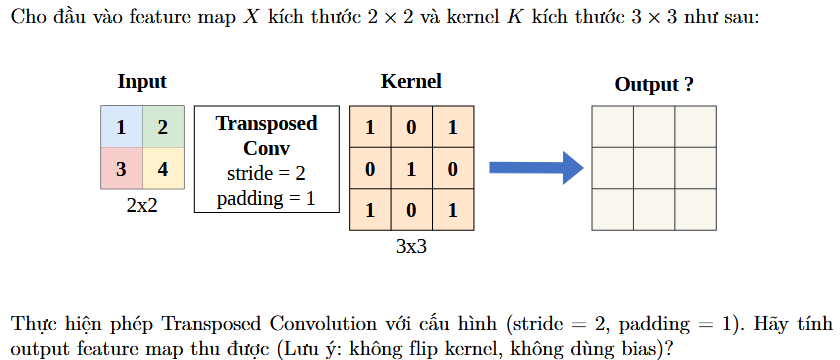

In [ ]:
import torch
from torch import nn

input = torch.tensor([[[1,2], [3,4]]], dtype=torch.float)
print(input.shape)
conv_layer = nn.ConvTranspose2d(in_channels=1, out_channels=1, padding=1, kernel_size=3, stride=2, bias=False)
conv_layer.weight.data = torch.tensor(
    [[[[1,0,1],
    [0,1,0],
    [1,0,1]]]], dtype=torch.float, requires_grad=True
)
out = conv_layer(input)
print(f'{out} - {out.shape}')

torch.Size([1, 2, 2])
tensor([[[ 1.,  0.,  2.],
         [ 0., 10.,  0.],
         [ 3.,  0.,  4.]]], grad_fn=<SqueezeBackward1>) - torch.Size([1, 3, 3])


In [14]:
from torch import nn

encoder = nn.Sequential(
    nn.Conv2d(1, 64, kernel_size=3, bias=False),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.Conv2d(64, 64, kernel_size=3, bias=False),
    nn.BatchNorm2d(64),
    nn.ReLU(),

    nn.Conv2d(64, 128, kernel_size=3, bias=False),
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.Conv2d(128, 128, kernel_size=3, bias=False),
    nn.BatchNorm2d(128),
    nn.ReLU(),

    nn.Conv2d(128, 256, kernel_size=3, bias=False),
    nn.BatchNorm2d(256),
    nn.ReLU(),
    nn.Conv2d(256, 256, kernel_size=3, bias=False),
    nn.BatchNorm2d(256),
    nn.ReLU(),
)

encoder

Sequential(
  (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU()
  (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (8): ReLU()
  (9): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (11): ReLU()
  (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (14): ReLU()
  (15): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (16): BatchNorm2d(256, eps=1e-05, momentum=0.1, affi

In [15]:
total_params = sum(p.numel() for p in encoder.parameters() if p.requires_grad)
print(f'Total number of parameters: {total_params}')

Total number of parameters: 1145152


In [13]:
for name, param in encoder.named_parameters():
    if param.requires_grad:
        print(f"{name}: {param.shape}")

0.weight: torch.Size([64, 1, 3, 3])
1.weight: torch.Size([64])
1.bias: torch.Size([64])
3.weight: torch.Size([64, 64, 3, 3])
4.weight: torch.Size([64])
4.bias: torch.Size([64])
6.weight: torch.Size([64, 1, 3, 3])
7.weight: torch.Size([64])
7.bias: torch.Size([64])
9.weight: torch.Size([64, 64, 3, 3])
10.weight: torch.Size([64])
10.bias: torch.Size([64])
12.weight: torch.Size([64, 1, 3, 3])
13.weight: torch.Size([64])
13.bias: torch.Size([64])
15.weight: torch.Size([64, 64, 3, 3])
16.weight: torch.Size([64])
16.bias: torch.Size([64])
